In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [45]:
df = pd.read_csv('ready_cleaned_df.csv')

In [46]:
df = df.drop(columns=['Unnamed: 0'])

In [47]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0


In [48]:
y = df['FWI']

In [49]:
X = df.drop('FWI', axis=1)

In [50]:
X_train,X_test, y_train, y_test = train_test_split(X,y,random_state=42)

## Robust Scaler

In [51]:
scaler = RobustScaler()
X_train_Upscaled = scaler.fit_transform(X_train)
X_test_Upscaled = scaler.transform(X_test)

Text(0.5, 1.0, 'X_train After Scaling')

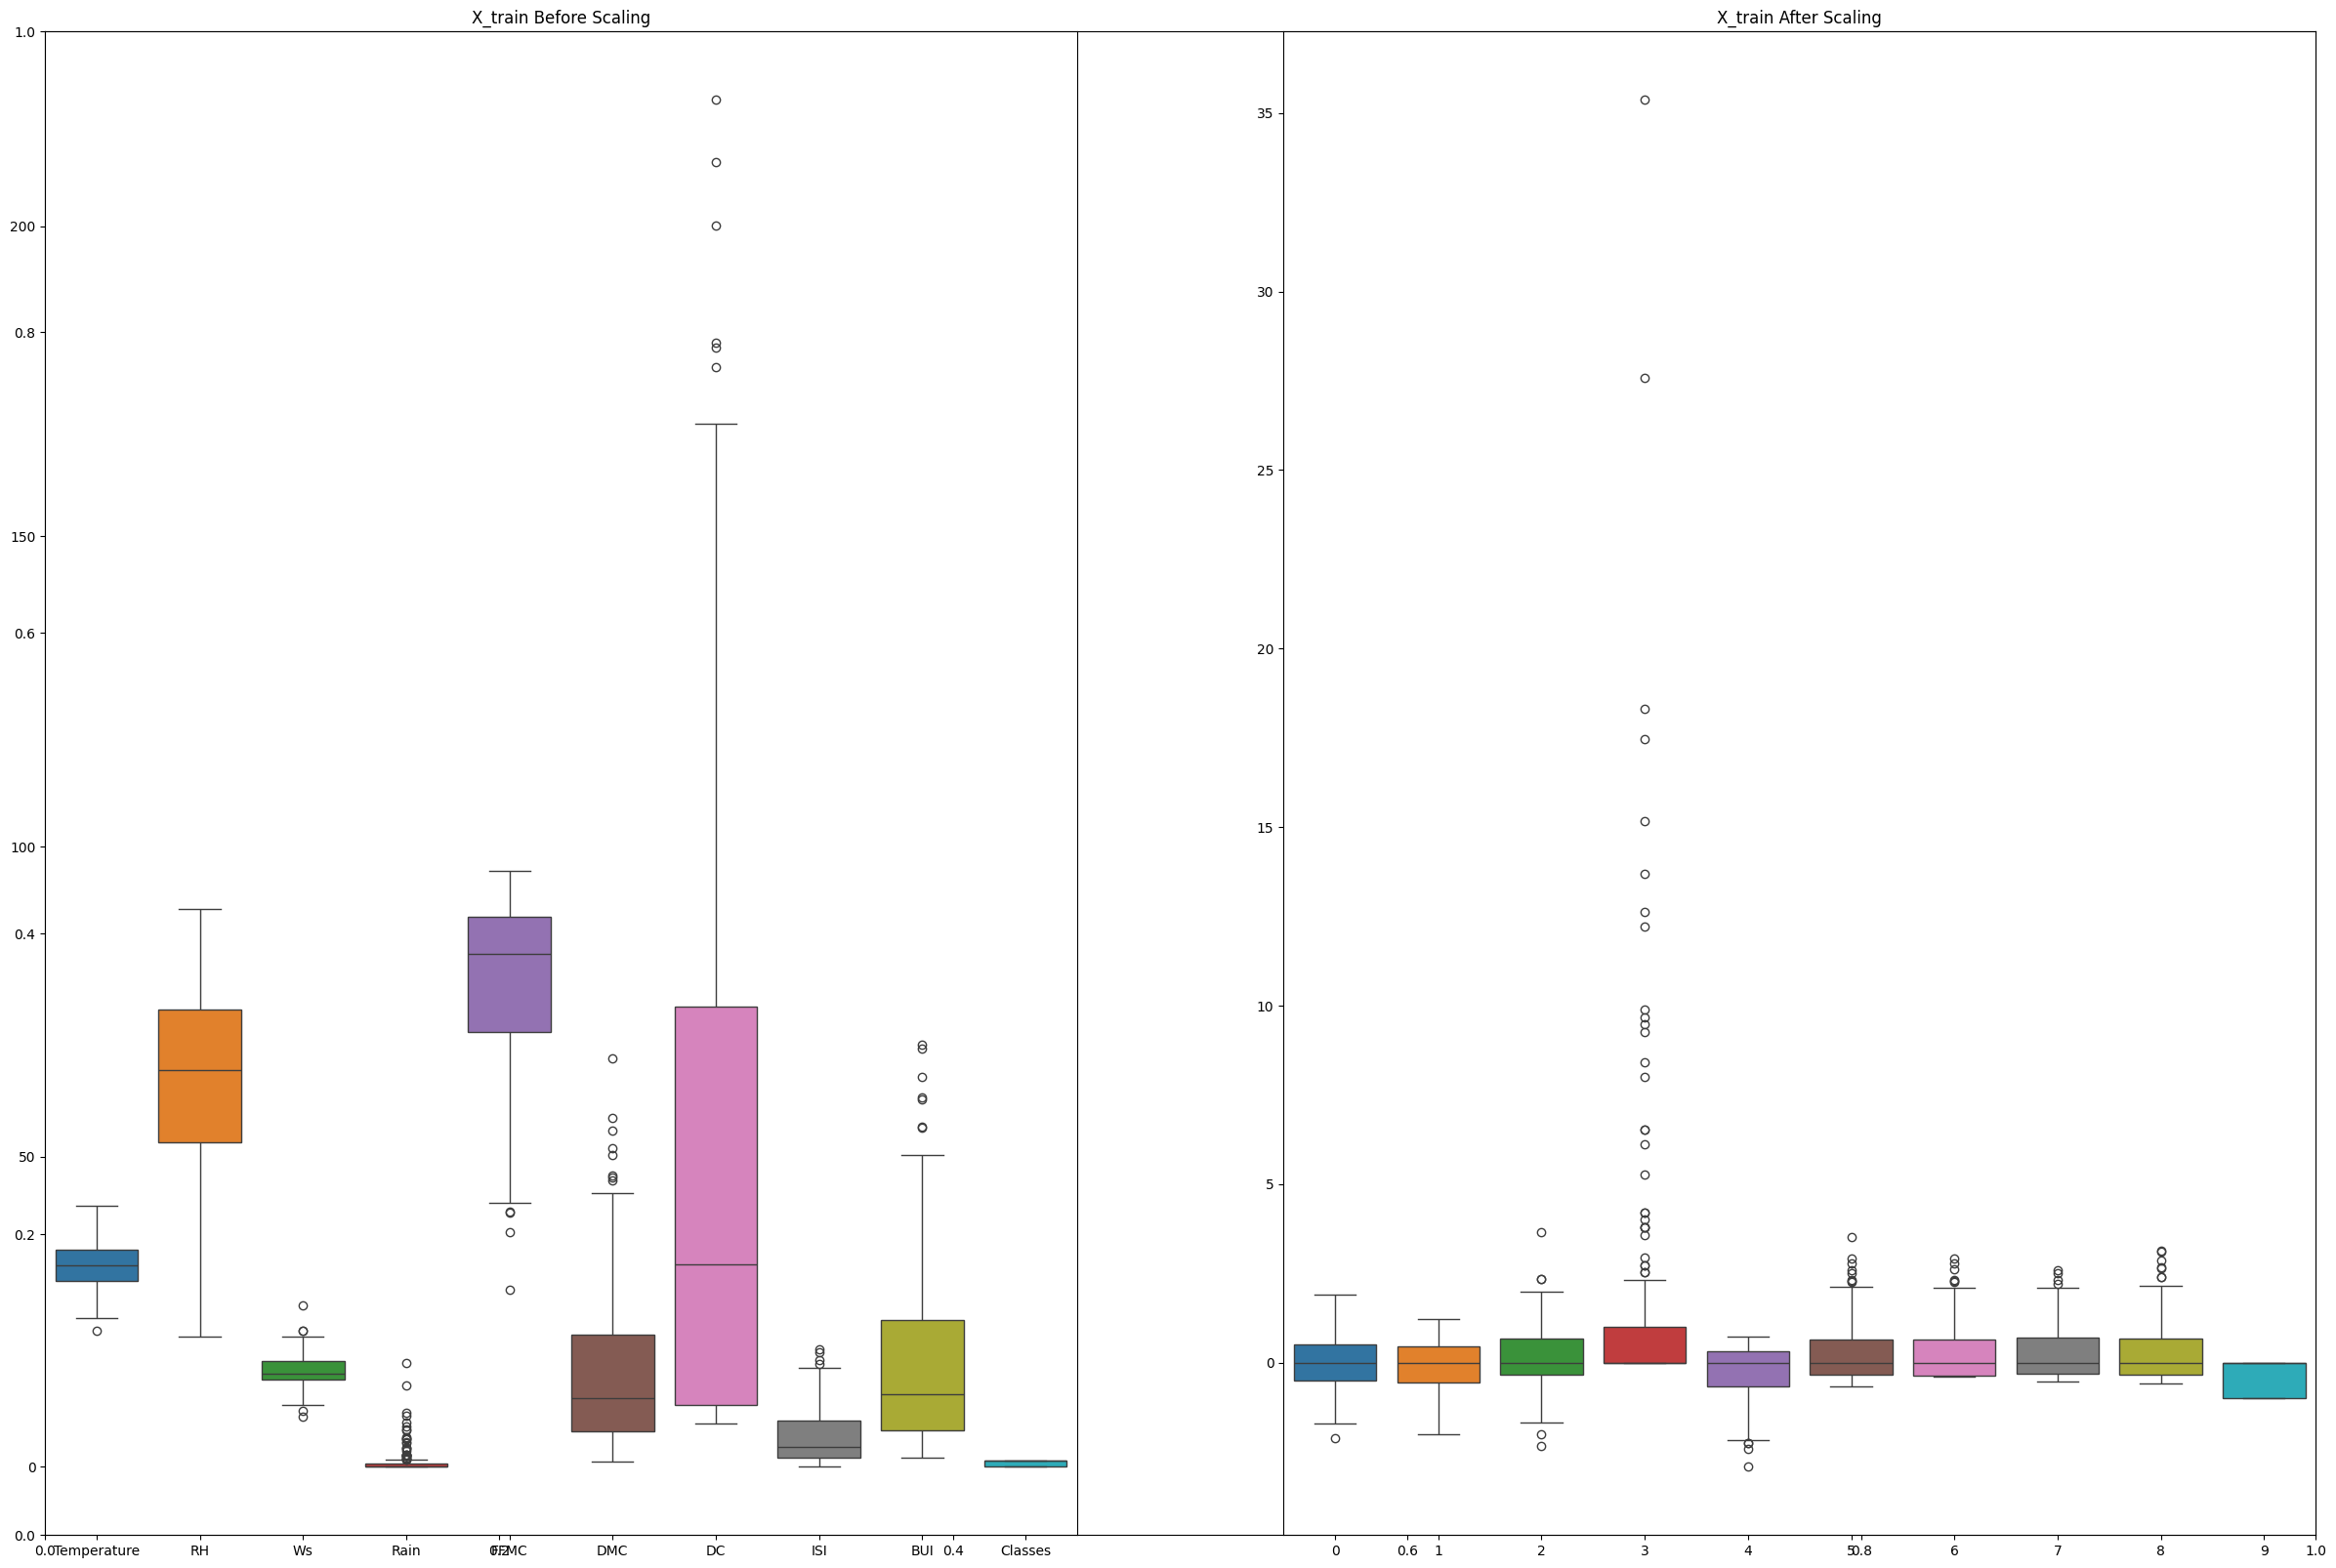

In [52]:
plt.subplots(figsize=(30, 20))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_Upscaled)
plt.title('X_train After Scaling')

## LinearRegression

In [53]:
linreg = LinearRegression()

In [54]:
linreg.fit(X_train_Upscaled, y_train)

LinearRegression()

In [55]:
predict = linreg.predict(X_test_Upscaled)

In [56]:
r2_score(y_test, predict)

0.988891586210307

In [57]:
mean_squared_error(y_test, predict)

0.4916644246988758

In [58]:
mean_absolute_error(y_test, predict)

0.4669258081963362

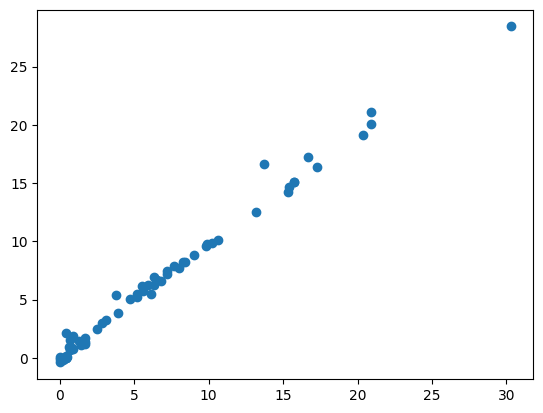

In [73]:
plt.scatter(y_test,predict)

## Ridge Regression

In [75]:
ridge = Ridge()
ridge.fit(X_train_Upscaled, y_train)
predict_ridge = ridge.predict(X_test_Upscaled)
r2_ridge = r2_score(y_test, predict_ridge)

## Lasso Regression

In [76]:
lasso = Lasso()
lasso.fit(X_train_Upscaled, y_train)
predict_lasso = lasso.predict(X_test_Upscaled)
r2_lasso = r2_score(y_test, predict_lasso)

## ElasticNet Regression

In [77]:
enet = ElasticNet()
enet.fit(X_train_Upscaled, y_train)
predict_enet = enet.predict(X_test_Upscaled)
r2_enet = r2_score(y_test, predict_enet)

## RidgeCV Regression 

In [107]:
ridgeCV = RidgeCV(cv=20)
ridgeCV.fit(X_train_Upscaled, y_train)
predict_ridgeCV = ridgeCV.predict(X_test_Upscaled)
r2_ridgeCV = r2_score(y_test, predict_ridgeCV)

## LassoCV Regression

In [108]:
lassoCV = LassoCV(cv=20)
lassoCV.fit(X_train_Upscaled, y_train)
predict_lassoCV = lassoCV.predict(X_test_Upscaled)
r2_lassoCV = r2_score(y_test, predict_lassoCV)

## ElasticNetCV Regression

In [110]:
enetCV = ElasticNetCV(cv=20)
enetCV.fit(X_train_Upscaled, y_train)
predict_enetCV = enetCV.predict(X_test_Upscaled)
r2_enetCV = r2_score(y_test, predict_enetCV)

In [112]:
regressions = {"Ridge": r2_ridge, "RidgeCV": r2_ridgeCV, "Lasso": r2_lasso, "LassoCV": r2_lassoCV, "ElasticNet": r2_enet, "ElasticNetCV": r2_enetCV}
df_regressions = pd.DataFrame([regressions])

In [83]:
df_regressions

,Ridge,RidgeCV,Lasso,LassoCV,ElasticNet,ElasticNetCV
0,0.98561,0.98561,0.933,0.986094,0.844733,0.981595


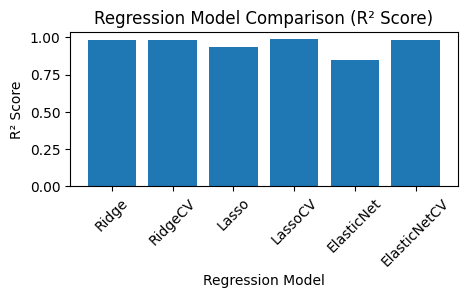

In [113]:
plt.figure(figsize=(5,2))
plt.bar(x=df_regressions.columns, height=df_regressions.iloc[0])
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison (R² Score)")
plt.xticks(rotation=45)
plt.show()

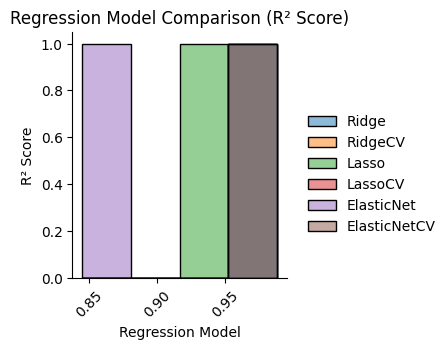

In [114]:
sns.displot(df_regressions, height=3)
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison (R² Score)")
plt.xticks(rotation=45)
plt.show()

## Best Alphas

In [115]:
print("Best alpha got in RidgeCV:")
print(ridgeCV.alpha_)
print("Best alpha got in LassoCV:")
print(lassoCV.alpha_)
print("Best alpha got in ElasticNetCV:")
print(enetCV.alpha_)

Best alpha got in RidgeCV:
1.0
Best alpha got in LassoCV:
0.027776291478334478
Best alpha got in ElasticNetCV:
0.022426673615568937
